In [22]:
import cv2 as cv 
import mediapipe as mp 
import time
import os 
import numpy as np
from pprint import pprint
from matplotlib import pyplot as plt

mp_holistic = mp.solutions.holistic
mp_hands = mp.solutions.hands

In [23]:

mp_drawing = mp.solutions.drawing_utils # drwaing utilites which is require . mhmm 


In [24]:
def mediapipe_detection(img, model):
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    img.flags.writeable = False         # image is no longer writeable means we are telling (mp , np , cv) to not do any changes in it why ? becuase in next line we are doing processing and during processing something bad can happen so we are just telling just in case hey guys this is just a read only stuff so dont touch it just detect the landmarks and done  
    results = model.process(img)                 # Make prediction
    img.flags.writeable = True               # image is now writeable , now image is writeable and everyone can do changes any it 
    img = cv.cvtColor(img, cv.COLOR_RGB2BGR) # color conversion from rgb to bgr because aage apn esko open cv k liye use karenge and open cv can only understand bgr frames
    return img, results

In [25]:
# def draw_landmarks(img , results):
#     mp_drawing.draw_landmarks(img , results.face_landmarks , mp_holistic.FACEMESH_TESSELATION) # draw face connections  
#     mp_drawing.draw_landmarks(img , results.pose_landmarks , mp_holistic.POSE_CONNECTIONS) # draw pose connections 
#     mp_drawing.draw_landmarks(img , results.left_hand_landmarks , mp_holistic.HAND_CONNECTIONS) # draw left hand landmarks
#     mp_drawing.draw_landmarks(img , results.right_hand_landmarks , mp_holistic.HAND_CONNECTIONS) # draw right hand landmarks 
    
    

In [26]:
def draw_styled_landmarks(img, results):
    # Draw face landmarks
    if results.face_landmarks:
        mp_drawing.draw_landmarks(
            img, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION,
            mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1))
    # Draw pose landmarks
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            img, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
            mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2))
    # Draw left hand landmarks
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            img, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
            mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2))
    # Draw right hand landmarks
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            img, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
            mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))

In [27]:
mp_drawing.draw_landmarks??

Signature:
mp_drawing.draw_landmarks(
    image: numpy.ndarray,
    landmark_list: mediapipe.framework.formats.landmark_pb2.NormalizedLandmarkList,
    connections: Optional[List[Tuple[int, int]]] = None,
    landmark_drawing_spec: Union[mediapipe.python.solutions.drawing_utils.DrawingSpec, Mapping[int, mediapipe.python.solutions.drawing_utils.DrawingSpec], NoneType] = DrawingSpec(color=(0, 0, 255), thickness=2, circle_radius=2),
    connection_drawing_spec: Union[mediapipe.python.solutions.drawing_utils.DrawingSpec, Mapping[Tuple[int, int], mediapipe.python.solutions.drawing_utils.DrawingSpec]] = DrawingSpec(color=(224, 224, 224), thickness=2, circle_radius=2),
    is_drawing_landmarks: bool = True,
)
Source:   
def draw_landmarks(
    image: np.ndarray,
    landmark_list: landmark_pb2.NormalizedLandmarkList,
    connections: Optional[List[Tuple[int, int]]] = None,
    landmark_drawing_spec: Optional[
        Union[DrawingSpec, Mapping[int, DrawingSpec]]
    ] = DrawingSpec(color=RED_

In [28]:
cap = cv.VideoCapture(0)
# Set mediapipe holistic model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
        # Read feed 
        ret, frame = cap.read()
        if not ret:
            break

        # Make detections
        img, results = mediapipe_detection(frame, holistic)

        # Draw landmarks
        draw_styled_landmarks(img, results)

        # Show detection
        cv.imshow('OpenCV Feed', img)

        # Break gracefully
        if cv.waitKey(1) & 0xFF == ord('d'):
            break

    cap.release()
    cv.destroyAllWindows()

In [29]:
# Inspect holistic detection results
if results.pose_landmarks:
    print(f"Pose: {len(results.pose_landmarks.landmark)} landmarks detected.")
if results.face_landmarks:
    print(f"Face: {len(results.face_landmarks.landmark)} landmarks detected.")
if results.left_hand_landmarks:
    print(f"Left Hand: {len(results.left_hand_landmarks.landmark)} landmarks detected.")
if results.right_hand_landmarks:
    print(f"Right Hand: {len(results.right_hand_landmarks.landmark)} landmarks detected.")

Pose: 33 landmarks detected.
Face: 468 landmarks detected.


In [30]:
frame

array([[[175, 170, 182],
        [175, 171, 184],
        [174, 172, 186],
        ...,
        [127, 120, 134],
        [130, 118, 133],
        [136, 122, 137]],

       [[173, 169, 181],
        [173, 170, 183],
        [170, 169, 182],
        ...,
        [139, 131, 144],
        [140, 129, 142],
        [139, 125, 139]],

       [[170, 168, 181],
        [172, 171, 183],
        [169, 171, 182],
        ...,
        [141, 131, 144],
        [144, 132, 144],
        [142, 130, 141]],

       ...,

       [[181, 193, 195],
        [189, 196, 199],
        [198, 196, 202],
        ...,
        [163, 166, 180],
        [164, 170, 179],
        [161, 169, 175]],

       [[177, 190, 193],
        [187, 194, 199],
        [198, 197, 204],
        ...,
        [165, 167, 180],
        [164, 168, 177],
        [164, 169, 175]],

       [[174, 187, 191],
        [186, 193, 199],
        [200, 198, 207],
        ...,
        [165, 166, 179],
        [165, 168, 177],
        [164, 167, 174]]

In [31]:
results

mediapipe.python.solution_base.SolutionOutputs

**NOTE : draw_landmarks function does not return the image but rather applies the landmark visuliazations to the current image in place**

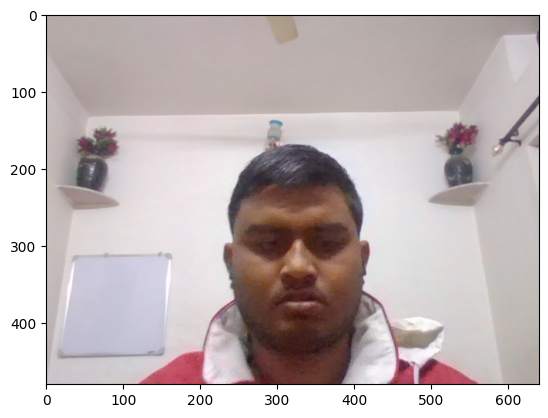

In [32]:
plt.imshow(cv.cvtColor(frame , cv.COLOR_BGR2RGB))

# EXTRACTING KEYPOINITS FROM LANDMARKS 

In [33]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x , res.y , res.z , res.visibility])
    pose.append(test)

In [34]:
pose = np.array([[res.x , res.y , res.z , res.visibility] for res in results.pose_landmarks.landmark]).flatten()  if results.pose_landmarks.landmark else np.zeros(132)
face = np.array([[res.x , res.y , res.z , ] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks.landmark else np.zeros(1404)
lh = np.array([[res.x , res.y , res.z , ] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x , res.y , res.z] for res in results.right_hand_landmarks.landmark]) if results.right_hand_landmarks else np.zeros(21*3)

In [35]:
face.shape

(1404,)

In [36]:
lh

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [37]:
pose.shape

(132,)

In [38]:
def extracting_keypoints(results):
    """Extract pose + hand keypoints (no face — it's noise for sign language)."""
    pose = np.array([[res.x, res.y, res.z, res.visibility] 
                     for res in results.pose_landmarks.landmark]).flatten() \
        if results.pose_landmarks else np.zeros(33 * 4)
    lh = np.array([[res.x, res.y, res.z] 
                   for res in results.left_hand_landmarks.landmark]).flatten() \
        if results.left_hand_landmarks else np.zeros(21 * 3)
    rh = np.array([[res.x, res.y, res.z] 
                   for res in results.right_hand_landmarks.landmark]).flatten() \
        if results.right_hand_landmarks else np.zeros(21 * 3)
    return np.concatenate([pose, lh, rh])  # 132 + 63 + 63 = 258 features

In [39]:
result_test = extracting_keypoints(results)

In [40]:
result_test

array([ 5.15060365e-01,  7.01644301e-01, -1.31170726e+00,  9.98529375e-01,
        5.50097048e-01,  6.25602484e-01, -1.24751770e+00,  9.98224795e-01,
        5.73614240e-01,  6.25234187e-01, -1.24795103e+00,  9.98140275e-01,
        5.93568087e-01,  6.25695109e-01, -1.24807131e+00,  9.97864187e-01,
        4.83332485e-01,  6.27684712e-01, -1.24678361e+00,  9.98388171e-01,
        4.61265624e-01,  6.28549337e-01, -1.24666810e+00,  9.98417258e-01,
        4.45181221e-01,  6.30965829e-01, -1.24730825e+00,  9.98467207e-01,
        6.28001213e-01,  6.52429819e-01, -7.22116947e-01,  9.98157144e-01,
        4.19380128e-01,  6.66604996e-01, -6.99569106e-01,  9.98543978e-01,
        5.59600949e-01,  7.86743224e-01, -1.10177398e+00,  9.97267723e-01,
        4.78162706e-01,  7.88466632e-01, -1.09697211e+00,  9.97708917e-01,
        7.95009315e-01,  9.86312568e-01, -3.50225121e-01,  9.35047388e-01,
        2.88484514e-01,  1.01448524e+00, -3.61466795e-01,  9.52981114e-01,
        9.12823498e-01,  

In [41]:
33*4+468*3+21*3+21*3

1662

In [42]:
np.save('0' , result_test)

In [43]:
np.load('0.npy')

array([ 5.15060365e-01,  7.01644301e-01, -1.31170726e+00,  9.98529375e-01,
        5.50097048e-01,  6.25602484e-01, -1.24751770e+00,  9.98224795e-01,
        5.73614240e-01,  6.25234187e-01, -1.24795103e+00,  9.98140275e-01,
        5.93568087e-01,  6.25695109e-01, -1.24807131e+00,  9.97864187e-01,
        4.83332485e-01,  6.27684712e-01, -1.24678361e+00,  9.98388171e-01,
        4.61265624e-01,  6.28549337e-01, -1.24666810e+00,  9.98417258e-01,
        4.45181221e-01,  6.30965829e-01, -1.24730825e+00,  9.98467207e-01,
        6.28001213e-01,  6.52429819e-01, -7.22116947e-01,  9.98157144e-01,
        4.19380128e-01,  6.66604996e-01, -6.99569106e-01,  9.98543978e-01,
        5.59600949e-01,  7.86743224e-01, -1.10177398e+00,  9.97267723e-01,
        4.78162706e-01,  7.88466632e-01, -1.09697211e+00,  9.97708917e-01,
        7.95009315e-01,  9.86312568e-01, -3.50225121e-01,  9.35047388e-01,
        2.88484514e-01,  1.01448524e+00, -3.61466795e-01,  9.52981114e-01,
        9.12823498e-01,  

# SETUP FOLDERS FOR COLLECTION OF OUR ARRAY , ARRAY WHY , TO STORE THE DATA IN ARRAY FOR TRAINING OF OUR LSTM MODEL  , AND IN ARRAY THERE IS COLLECTION OF KEYPOINS OF OUR LANDMARKS 

## NOTE: ACTION DETECTION  = A KEY DIFFERENCE BTW ACTION DETECTION AND OTHER COMPUTER VISION TASKS IS THAT A SEQUENCE OF DATA RATHER THAN A SINGLE FRAME IS USED FOR DTECTION 

In [44]:
# path for extractiog the data 
DATA_PATH = os.path.join('MP_Data')
# Your class labels (order matters for indexing)
actions = np.array(['hello' , 'thanks' , 'okay' , 'iloveyou'])
# thiry videos worth of data 
no_sequences = 30
# videos are going to be 30 frames in length 
squences_length = 30 

# data = we are going to collect 30   videos per action it means hello , thanks , ily , okay

# then each one of those video sequences are going to contain 30 frames of data . each frame will contain 1662 landmark values it means 30 frames , 1662 landmarks

In [45]:
# hello 
## 0  , there is going  to be 30 frames and so on 
## 1 
## 2 
# ...
# 29

# thanks 
#....
# ily 
#....
#okay
#...
# and so on 

In [46]:
for action in actions:
    for sequence in range(no_sequences):
        try:
            os.makedirs(os.path.join(DATA_PATH, action , str(sequence)))
        
        except:
            pass    

# COLLECT KEYPOINT VALUES FOR TRAINING AND TESTING 

In [47]:
cap = cv.VideoCapture(0)
# now set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5 , min_tracking_confidence=0.5) as holistic:
    # NEW LOOP
    #loop through each action
    for action in actions:
        # loop through each sequence
        for sequence in range(no_sequences):
            # loop through each frames
            for frame_num in range(squences_length):
                # read feed 
                ret , frame = cap.read()
                
                
                
                # make detections 
                img , results = mediapipe_detection(frame , holistic)
                print(results)
                
                # draw the landmarks 
                draw_styled_landmarks(img , results)
                
                # NEW LOGIC 
                # apply wait logic 
                if frame_num == 0:
                    cv.putText(img , 'STARING COLLECTION' , (120,100) ,
                               cv.FONT_HERSHEY_SIMPLEX , 1 , (0,255,0) , 4 , cv.LINE_AA)
                    cv.putText(img , 'COLLECTING FRAMES FOR {} Video Number {}'.format(action , sequence), (15 , 12),cv.FONT_HERSHEY_SIMPLEX , 0.5 , (0,0,255) , 1 , cv.LINE_AA)
                    if cv.waitKey(4000) & 0xFF== ord('d'):
                        break
                else:
                      cv.putText(img , 'COLLECTING FRAMES FOR {} Video Number {}'.format(action , sequence), (15 , 12),cv.FONT_HERSHEY_SIMPLEX , 0.5 , (0,0,255) , 1 , cv.LINE_AA)
                    
                
                # NEW EXPORT KEYPOINTS
                keypoint = extracting_keypoints(results)
                npy_path = os.path.join(DATA_PATH , action, str(sequence) , str(frame_num))
                np.save(npy_path , keypoint)
                
                # show the detection  or screen 
                cv.imshow('OPEN CV FEED ' , img)
                
                
                
                # we have to applly little bit of logic here , which is collection breaks why ?  = because this code is going to collect keypoints so damn fast that we barely have time to collect those different frames 
                # collection breaks = having breaks between each sequence collection allows you to rest and reposition yourself to collect the action from start to finish 
                
        
                # break fluidlly 
                if cv.waitKey(10) & 0xFF == ord('d'):
                    break
       
cap.release()
cv.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [48]:
cap.release()
cv.destroyAllWindows()

# preprocess data and create labels 

In [49]:
from sklearn.model_selection import train_test_split
import tensorflow as tf


In [50]:
label_map  = {label:num for num  , label in enumerate(actions)}


In [51]:
label_map

{'hello': 0, 'thanks': 1, 'okay': 2, 'iloveyou': 3}

In [68]:
# Load sequences — handle both old (1662-dim) and new (258-dim) saved data
# Old format: pose(132) + face(1404) + lh(63) + rh(63) = 1662
# New format: pose(132) + lh(63) + rh(63) = 258  (face already removed)

sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(squences_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            if res.shape[0] == 1662:
                # Old format: strip face landmarks
                res = np.concatenate([res[:132], res[1536:]])
            # else: already 258 features, use as-is
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

print(f"Loaded {len(sequences)} sequences, each with {len(sequences[0])} frames of {len(sequences[0][0])} features")

Loaded 120 sequences, each with 30 frames of 258 features


In [53]:
np.array(sequences).shape


(120, 30, 132)

In [54]:
np.array(labels).shape 

(120,)

In [69]:
X = np.array(sequences)


In [56]:
X.shape

(120, 30, 132)

In [70]:
y = tf.keras.utils.to_categorical(labels).astype(int)

In [58]:
y

array([[1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [0, 1,

In [71]:
# 20% test split gives ~24 test samples instead of 6
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [60]:
X_test.shape

(24, 30, 132)

In [61]:
y_test.shape

(24, 4)

In [62]:
# NOTE: StandardScaler removed — MediaPipe landmarks are already normalized to [0,1] range.
# No additional scaling is needed, and removing it avoids needing to save/load
# a scaler object for real-time inference.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (96, 30, 132)
X_test shape: (24, 30, 132)
y_train shape: (96, 4)
y_test shape: (24, 4)


# 7. Build and Train LSTM Neural Network

In [73]:
import tensorflow as tf 

In [74]:
log_dir = os.path.join('logs')
tb_callback = tf.keras.callbacks.TensorBoard(log_dir = log_dir)

In [75]:
# Improved model: simpler architecture with dropout to prevent overfitting
# Input shape changed from (30, 1662) to (30, 258) after removing face landmarks
NUM_FEATURES = 258  # pose(132) + lh(63) + rh(63)

model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, activation='relu', input_shape=(30, NUM_FEATURES)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(128, return_sequences=True, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(64, return_sequences=False, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(actions.shape[0], activation='softmax')
])

model.summary()

d:\Open-Cv_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 64)         │        82,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,284 (926.89 KB)

 Trainable params: 237,284 (926.89 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
print(y_train[0])
print(res[0])



[0 1 0 0]
[0.29617837 0.19194546 0.33047026 0.18140595]


In [77]:
res = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step


In [78]:
print("res.shape:", res.shape)
print("res:", res)
print("actions:", actions)
print("argmax:", np.argmax(res))




res.shape: (24, 4)
res: [[0.2666681  0.24430317 0.23540814 0.2536205 ]
 [0.2608605  0.24183182 0.24100764 0.2563    ]
 [0.2622599  0.24257833 0.2391771  0.2559847 ]
 [0.2572343  0.24331005 0.23929666 0.26015896]
 [0.25915095 0.26621947 0.23330149 0.24132808]
 [0.25477627 0.24936932 0.2379752  0.25787923]
 [0.25582716 0.25520977 0.23683463 0.25212842]
 [0.26032153 0.26319236 0.23532906 0.24115703]
 [0.2582945  0.269415   0.23407592 0.23821466]
 [0.25920025 0.253117   0.23422082 0.25346193]
 [0.25694737 0.26479325 0.23714341 0.24111591]
 [0.25603688 0.2653473  0.23793876 0.24067701]
 [0.25583664 0.2651719  0.23676759 0.2422238 ]
 [0.2552327  0.2507326  0.23792364 0.2561111 ]
 [0.2568439  0.24489708 0.23824947 0.26000962]
 [0.2624849  0.24621037 0.236016   0.2552887 ]
 [0.2595852  0.2556246  0.23291941 0.2518708 ]
 [0.25023532 0.26001757 0.2375288  0.2522183 ]
 [0.2539324  0.2526693  0.23604392 0.25735438]
 [0.2527998  0.25240418 0.23687911 0.2579169 ]
 [0.25742117 0.2456597  0.23863666 0

In [79]:
print(res.shape)     # e.g., (1, 13)

(24, 4)


In [80]:
# NOTE: Run this cell AFTER model.compile() and model.fit() below.
# Before training, predictions are random and argmax may be out of bounds.
# actions[np.argmax(res)]

In [81]:
# Lower learning rate for more stable convergence
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

In [82]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=30,               # more patience — small dataset needs time
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6
)

In [83]:
# Scaling step removed — using raw normalized MediaPipe landmarks directly.
# This keeps the pipeline simple and consistent between training and real-time inference.

In [84]:
history = model.fit(
    X_train, y_train,
    epochs=300,
    validation_split=0.15,
    batch_size=16,
    callbacks=[tb_callback, early_stop, reduce_lr],
    verbose=1
)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - categorical_accuracy: 0.2653 - loss: 1.3859 - val_categorical_accuracy: 0.2000 - val_loss: 1.3722 - learning_rate: 5.0000e-04
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - categorical_accuracy: 0.4381 - loss: 1.2981 - val_categorical_accuracy: 0.2000 - val_loss: 1.3279 - learning_rate: 5.0000e-04
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - categorical_accuracy: 0.4955 - loss: 1.2271 - val_categorical_accuracy: 0.1333 - val_loss: 1.5795 - learning_rate: 5.0000e-04
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - categorical_accuracy: 0.4187 - loss: 1.2325 - val_categorical_accuracy: 0.2000 - val_loss: 1.3876 - learning_rate: 5.0000e-04
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - categorical_accuracy: 0.5251 - loss: 1.1162 - val_categorical_accuracy: 0.1333 - val_loss: 1.5427 - learning_rate: 5.0000e-04
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - categorical_accuracy: 0.4823 - loss: 1.2165 - val_categor

In [85]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 64)         │        82,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 711,854 (2.72 MB)

 Trainable params: 237,284 (926.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 474,570 (1.81 MB)

# 8. make predictions 

In [86]:
# Predict on test set AFTER training
res = model.predict(X_test)
print("Test predictions shape:", res.shape)

# Show per-sample predictions vs actuals
print("\n--- Test Set Results ---")
correct = 0
for i in range(len(y_test)):
    predicted = actions[np.argmax(res[i])]
    actual = actions[np.argmax(y_test[i])]
    match = "✓" if predicted == actual else "✗"
    correct += (predicted == actual)
    print(f"  Sample {i}: Predicted={predicted:10s}  Actual={actual:10s}  {match}  (conf: {res[i][np.argmax(res[i])]:.2f})")

print(f"\nTest Accuracy: {correct}/{len(y_test)} = {correct/len(y_test)*100:.1f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
Test predictions shape: (24, 4)

--- Test Set Results ---
  Sample 0: Predicted=thanks      Actual=thanks      ✓  (conf: 1.00)
  Sample 1: Predicted=thanks      Actual=thanks      ✓  (conf: 0.99)
  Sample 2: Predicted=thanks      Actual=thanks      ✓  (conf: 1.00)
  Sample 3: Predicted=hello       Actual=hello       ✓  (conf: 1.00)
  Sample 4: Predicted=iloveyou    Actual=okay        ✗  (conf: 0.59)
  Sample 5: Predicted=iloveyou    Actual=iloveyou    ✓  (conf: 0.56)
  Sample 6: Predicted=iloveyou    Actual=okay        ✗  (conf: 0.58)
  Sample 7: Predicted=iloveyou    Actual=iloveyou    ✓  (conf: 0.75)
  Sample 8: Predicted=okay        Actual=okay        ✓  (conf: 0.75)
  Sample 9: Predicted=thanks      Actual=thanks      ✓  (conf: 0.90)
  Sample 10: Predicted=hello       Actual=hello       ✓  (conf: 1.00)
  Sample 11: Predicted=hello       Actual=hello       ✓  (conf: 1.00)
  Sample 12: Predicted=iloveyou    Actual=iloveyou    ✓  (conf: 0.68)
  S

In [87]:
# show preiction output shape 
print(actions)
print("Max indices from res:")
for i in range(len(res)):
    print(np.argmax(res[i]))


['hello' 'thanks' 'okay' 'iloveyou']
Max indices from res:
1
1
1
0
3
3
3
3
2
1
0
0
3
3
0
1
1
3
3
3
0
0
3
0


In [88]:
# final prediction comparision (with actual labels) 
for i in range(len(y_test)):
    predicted = actions[np.argmax(res[i])]
    actual = actions[np.argmax(y_test[i])]
    
    print(f"Sample {i} → Predicted: {predicted}, Actual: {actual}")


Sample 0 → Predicted: thanks, Actual: thanks
Sample 1 → Predicted: thanks, Actual: thanks
Sample 2 → Predicted: thanks, Actual: thanks
Sample 3 → Predicted: hello, Actual: hello
Sample 4 → Predicted: iloveyou, Actual: okay
Sample 5 → Predicted: iloveyou, Actual: iloveyou
Sample 6 → Predicted: iloveyou, Actual: okay
Sample 7 → Predicted: iloveyou, Actual: iloveyou
Sample 8 → Predicted: okay, Actual: okay
Sample 9 → Predicted: thanks, Actual: thanks
Sample 10 → Predicted: hello, Actual: hello
Sample 11 → Predicted: hello, Actual: hello
Sample 12 → Predicted: iloveyou, Actual: iloveyou
Sample 13 → Predicted: iloveyou, Actual: okay
Sample 14 → Predicted: hello, Actual: hello
Sample 15 → Predicted: thanks, Actual: thanks
Sample 16 → Predicted: thanks, Actual: thanks
Sample 17 → Predicted: iloveyou, Actual: okay
Sample 18 → Predicted: iloveyou, Actual: iloveyou
Sample 19 → Predicted: iloveyou, Actual: iloveyou
Sample 20 → Predicted: hello, Actual: okay
Sample 21 → Predicted: hello, Actual: h

# SAVE WEIGHTS 

In [89]:
model.save('action.h5')

In [90]:
del model

In [91]:
# Reload the model from disk (after del model above)
model = tf.keras.models.load_model('action.h5')

# EVALUTION USING CONFUSION MATRIX AND ACCURACY 

# conversion = running these cells converts the predictions from their one-hot encoded representation to a categorical label ex = 0,1 or 2 as opposed to [1 ,0,0] , # [0,1,0] , [0,0,1]

In [92]:
from sklearn.metrics import multilabel_confusion_matrix , accuracy_score

In [93]:
# Evaluate on TEST set (not train set — that would be misleading)
yhat = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


In [94]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [95]:
multilabel_confusion_matrix(ytrue , yhat)

array([[[17,  1],
        [ 0,  6]],

       [[18,  0],
        [ 0,  6]],

       [[18,  0],
        [ 5,  1]],

       [[14,  4],
        [ 0,  6]]], dtype=int64)

confusion matrix = the mcm function returns a confusion matrix sorted by the label order , in this case , 0,1,2 aka hello , thank , ily. 
the matrix is organised as follows :[TRUE N , FLASE P ],
[FALSE N , TRUE P ]

In [96]:
accuracy_score(ytrue , yhat)

0.7916666666666666

# 11. TEST IN REAL TIME 


In [ ]:
# ============================================================
# REAL-TIME SIGN LANGUAGE DETECTION (Improved Pipeline)
# ============================================================
# - Shows ONLY the current prediction (replaces previous)
# - Stability filter: waits for N consistent frames before updating
# - Confidence bar visualization
# - Logs entire session for summary after closing
# Press 'D' to quit

import time as _time

# --- Config ---
THRESHOLD = 0.6          # minimum confidence to show a prediction
STABILITY_FRAMES = 10    # must see same sign for N frames to confirm
COLORS = {
    'hello':    (0, 255, 0),    # green
    'thanks':   (255, 165, 0),  # orange
    'okay':     (0, 255, 255),  # yellow
    'iloveyou': (255, 0, 255),  # magenta
}

# --- State ---
sequence = []
current_sign = ""
current_conf = 0.0
stability_counter = 0
last_candidate = ""
session_log = []           # list of (timestamp, sign, confidence)
frame_count = 0

cap = cv.VideoCapture(0)
start_time = _time.time()

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1
        
        # --- Detection ---
        img, results = mediapipe_detection(frame, holistic)
        draw_styled_landmarks(img, results)
        
        # --- Build sequence ---
        keypoints = extracting_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        # --- Prediction ---
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0), verbose=0)[0]
            top_idx = np.argmax(res)
            top_conf = res[top_idx]
            candidate = actions[top_idx]
            
            # Stability filter: only update if same sign seen consistently
            if candidate == last_candidate and top_conf > THRESHOLD:
                stability_counter += 1
            else:
                stability_counter = 1
                last_candidate = candidate
            
            # Confirm new sign after enough stable frames
            if stability_counter >= STABILITY_FRAMES:
                if candidate != current_sign:
                    # Log the transition
                    elapsed = _time.time() - start_time
                    session_log.append((elapsed, candidate, top_conf))
                    current_sign = candidate
                    current_conf = top_conf
                    print(f"[{elapsed:6.1f}s] Detected: {candidate} (conf: {top_conf:.2f})")
            
            # Update confidence for display even if sign hasn't changed
            if candidate == current_sign:
                current_conf = top_conf
        
        # --- Visualization ---
        h, w = img.shape[:2]
        
        # Top bar: current prediction
        cv.rectangle(img, (0, 0), (w, 50), (30, 30, 30), -1)
        
        if current_sign:
            color = COLORS.get(current_sign, (255, 255, 255))
            
            # Sign name (large)
            cv.putText(img, current_sign.upper(), (10, 38),
                       cv.FONT_HERSHEY_SIMPLEX, 1.2, color, 3, cv.LINE_AA)
            
            # Confidence bar
            bar_x = 280
            bar_w = 200
            bar_h = 20
            bar_y = 15
            cv.rectangle(img, (bar_x, bar_y), (bar_x + bar_w, bar_y + bar_h), (80, 80, 80), -1)
            fill_w = int(bar_w * current_conf)
            bar_color = (0, 255, 0) if current_conf > 0.8 else (0, 255, 255) if current_conf > 0.6 else (0, 0, 255)
            cv.rectangle(img, (bar_x, bar_y), (bar_x + fill_w, bar_y + bar_h), bar_color, -1)
            cv.putText(img, f"{current_conf:.0%}", (bar_x + bar_w + 10, bar_y + 16),
                       cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv.LINE_AA)
        else:
            cv.putText(img, "Show a sign...", (10, 35),
                       cv.FONT_HERSHEY_SIMPLEX, 0.8, (150, 150, 150), 2, cv.LINE_AA)
        
        # Bottom bar: all class probabilities (mini bar chart)
        if len(sequence) == 30:
            bottom_y = h - 40
            cv.rectangle(img, (0, bottom_y - 5), (w, h), (30, 30, 30), -1)
            bar_total_w = w - 20
            x_offset = 10
            for i, act in enumerate(actions):
                prob = res[i]
                act_w = bar_total_w // len(actions) - 5
                act_color = COLORS.get(act, (200, 200, 200))
                # Background
                cv.rectangle(img, (x_offset, bottom_y), (x_offset + act_w, h - 5), (60, 60, 60), -1)
                # Fill
                fill = int(act_w * prob)
                cv.rectangle(img, (x_offset, bottom_y), (x_offset + fill, h - 5), act_color, -1)
                # Label
                cv.putText(img, f"{act[:3]} {prob:.0%}", (x_offset + 2, h - 10),
                           cv.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv.LINE_AA)
                x_offset += act_w + 5
        
        # FPS counter
        fps = frame_count / (_time.time() - start_time + 0.001)
        cv.putText(img, f"FPS: {fps:.0f}", (w - 100, 70),
                   cv.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1, cv.LINE_AA)
        
        cv.imshow('Sign Language Detection', img)
        
        if cv.waitKey(10) & 0xFF == ord('d'):
            break

cap.release()
cv.destroyAllWindows()

# --- Print session summary ---
total_time = _time.time() - start_time
print(f"\n{'='*50}")
print(f"SESSION SUMMARY")
print(f"{'='*50}")
print(f"Duration: {total_time:.1f}s | Frames: {frame_count} | Avg FPS: {frame_count/total_time:.1f}")
print(f"Total signs detected: {len(session_log)}")
if session_log:
    print(f"\nTimeline:")
    for t, sign, conf in session_log:
        print(f"  [{t:6.1f}s] {sign:<12s} (confidence: {conf:.2f})")
    
    # Count per class
    from collections import Counter
    sign_counts = Counter(s for _, s, _ in session_log)
    print(f"\nSign frequency:")
    for sign, count in sign_counts.most_common():
        print(f"  {sign}: {count} times")
    
    avg_conf = np.mean([c for _, _, c in session_log])
    print(f"\nAverage confidence: {avg_conf:.2f}")
else:
    print("No signs were detected during this session.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted: hello (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted: hello (1.00)
1/1 ━━━

In [98]:
np.expand_dims(X_test[0] , axis=0)

array([[[ 4.33587939e-01,  3.64388824e-01, -8.90518367e-01, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 5.26638031e-01,  3.70279133e-01, -6.96951091e-01, ...,
          5.82218647e-01,  4.60666448e-01,  1.31265400e-03],
        [ 5.43088317e-01,  3.71924996e-01, -7.29947269e-01, ...,
          5.79209149e-01,  4.50112015e-01,  5.05360367e-04],
        ...,
        [ 5.70739090e-01,  3.67652148e-01, -6.61972344e-01, ...,
          8.35614443e-01,  6.03402972e-01, -1.63242791e-03],
        [ 5.70865452e-01,  3.67349654e-01, -6.78908348e-01, ...,
          8.33804250e-01,  6.03409708e-01,  5.29772788e-03],
        [ 5.70168972e-01,  3.67296338e-01, -6.95478201e-01, ...,
          8.28031898e-01,  6.05028749e-01,  4.83487360e-03]]])

In [103]:
# Expected shape: (num_sequences, 30 frames, 258 features)
print("X_test shape:", X_test.shape)

X_test shape: (24, 30, 258)


In [104]:
model.predict(np.expand_dims(X_test[0] , axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([[4.1318018e-10, 9.9998319e-01, 1.6832988e-05, 4.3034348e-16]],
      dtype=float32)

In [105]:
cap.release
cv.destroyAllWindows()

In [106]:
print(res[0])  # should look like [0.01, 0.02, 0.95, 0.02]

0.77607876


In [ ]:
# 12. HYPERPARAMETER TUNING
W'll systematically search over different architectures, learning rates, dropout rates, and batch sizes to find the best configuration. Current baseline: **79.2%** accuracy.

In [107]:
import itertools
from sklearn.model_selection import StratifiedKFold

def build_model(lstm_units, dropout_rate, learning_rate, dense_units, num_features=258, num_classes=4):
    """Build an LSTM model with given hyperparameters."""
    model = tf.keras.models.Sequential([
        tf.keras.layers.LSTM(lstm_units[0], return_sequences=True, activation='relu', input_shape=(30, num_features)),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.LSTM(lstm_units[1], return_sequences=True, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.LSTM(lstm_units[2], return_sequences=False, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(dense_units, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate + 0.1),
        tf.keras.layers.Dense(dense_units // 2, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['categorical_accuracy']
    )
    return model

# --- Hyperparameter Search Space ---
param_grid = {
    'lstm_units': [
        (64, 128, 64),     # current architecture
        (128, 256, 128),   # wider
        (64, 64, 64),      # uniform
        (32, 64, 32),      # smaller/faster
    ],
    'dropout_rate': [0.2, 0.3, 0.4],
    'learning_rate': [0.001, 0.0005, 0.0001],
    'dense_units': [64, 128],
    'batch_size': [8, 16, 32],
}

print(f"Search space:")
total = 1
for k, v in param_grid.items():
    print(f"  {k}: {v}")
    total *= len(v)
print(f"\nTotal combinations: {total}")
print("We'll use 3-fold cross-validation on training data to evaluate each config.")
print("To keep it feasible, we'll sample the most promising combinations.")

Search space:
  lstm_units: [(64, 128, 64), (128, 256, 128), (64, 64, 64), (32, 64, 32)]
  dropout_rate: [0.2, 0.3, 0.4]
  learning_rate: [0.001, 0.0005, 0.0001]
  dense_units: [64, 128]
  batch_size: [8, 16, 32]

Total combinations: 216
We'll use 3-fold cross-validation on training data to evaluate each config.
To keep it feasible, we'll sample the most promising combinations.


In [108]:
# --- Smart Grid Search with 3-Fold CV ---
# Instead of exhaustive search (324 combos), we test targeted combinations
# focusing on the parameters most likely to matter

configs = [
    # (lstm_units, dropout, lr, dense_units, batch_size, label)
    # Vary architecture
    ((64, 128, 64),   0.2, 0.0005, 64,  16, "baseline"),
    ((128, 256, 128), 0.2, 0.0005, 64,  16, "wider_lstm"),
    ((64, 64, 64),    0.2, 0.0005, 64,  16, "uniform_lstm"),
    ((32, 64, 32),    0.2, 0.0005, 64,  16, "smaller_lstm"),
    # Vary dropout
    ((64, 128, 64),   0.3, 0.0005, 64,  16, "higher_dropout"),
    ((64, 128, 64),   0.4, 0.0005, 64,  16, "highest_dropout"),
    # Vary learning rate
    ((64, 128, 64),   0.2, 0.001,  64,  16, "higher_lr"),
    ((64, 128, 64),   0.2, 0.0001, 64,  16, "lower_lr"),
    # Vary dense units
    ((64, 128, 64),   0.2, 0.0005, 128, 16, "bigger_dense"),
    ((128, 256, 128), 0.3, 0.0005, 128, 16, "wide+dense+drop"),
    # Vary batch size
    ((64, 128, 64),   0.2, 0.0005, 64,  8,  "small_batch"),
    ((64, 128, 64),   0.2, 0.0005, 64,  32, "large_batch"),
    # Best guess combos
    ((128, 256, 128), 0.3, 0.0001, 128, 8,  "combo_deep_slow"),
    ((64, 128, 64),   0.3, 0.001,  128, 16, "combo_fast_reg"),
    ((128, 256, 128), 0.2, 0.0005, 64,  8,  "combo_wide_small"),
]

# Use full X and y (not just X_train) with cross-validation for better estimates
X_full = X  # (120, 30, 258)
y_full_labels = np.argmax(y, axis=1)  # integer labels for stratified split

results = []
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print(f"Running {len(configs)} configurations with 3-fold CV...\n")
print(f"{'#':<3} {'Config':<20} {'Fold1':>6} {'Fold2':>6} {'Fold3':>6} {'Mean':>6} {'Std':>6}")
print("-" * 60)

for idx, (lstm_u, drop, lr, dense, batch, label) in enumerate(configs):
    fold_accs = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full_labels)):
        X_tr, X_val = X_full[train_idx], X_full[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        # Build fresh model
        m = build_model(lstm_u, drop, lr, dense)
        
        # Train silently
        early = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20, restore_best_weights=True
        )
        rlr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6
        )
        
        m.fit(X_tr, y_tr, epochs=200, batch_size=batch,
              validation_data=(X_val, y_val),
              callbacks=[early, rlr], verbose=0)
        
        # Evaluate
        _, acc = m.evaluate(X_val, y_val, verbose=0)
        fold_accs.append(acc)
        
        # Clean up
        del m
        tf.keras.backend.clear_session()
    
    mean_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    results.append((label, lstm_u, drop, lr, dense, batch, mean_acc, std_acc, fold_accs))
    
    print(f"{idx+1:<3} {label:<20} {fold_accs[0]:>5.1%} {fold_accs[1]:>5.1%} {fold_accs[2]:>5.1%} {mean_acc:>5.1%} {std_acc:>5.1%}")

print("\nDone!")

Running 15 configurations with 3-fold CV...

#   Config                Fold1  Fold2  Fold3   Mean    Std
------------------------------------------------------------


d:\Open-Cv_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1   baseline             82.5% 92.5% 77.5% 84.2%  6.2%


d:\Open-Cv_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2   wider_lstm           62.5% 87.5% 70.0% 73.3% 10.5%


...

13  combo_deep_slow      45.0% 92.5% 75.0% 70.8% 19.6%


d:\Open-Cv_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14  combo_fast_reg       52.5% 92.5% 72.5% 72.5% 16.3%


d:\Open-Cv_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15  combo_wide_small     67.5% 90.0% 87.5% 81.7% 10.1%

Done!


In [109]:
# --- Show Results Ranked ---
results_sorted = sorted(results, key=lambda x: x[6], reverse=True)

print(f"\n{'Rank':<5} {'Config':<20} {'LSTM Units':<18} {'Drop':>5} {'LR':>8} {'Dense':>6} {'Batch':>6} {'Mean Acc':>9} {'Std':>6}")
print("=" * 95)
for rank, (label, lstm_u, drop, lr, dense, batch, mean_acc, std_acc, _) in enumerate(results_sorted, 1):
    marker = " ★" if rank <= 3 else ""
    print(f"{rank:<5} {label:<20} {str(lstm_u):<18} {drop:>5.2f} {lr:>8.4f} {dense:>6} {batch:>6} {mean_acc:>8.1%} {std_acc:>5.1%}{marker}")

best = results_sorted[0]
print(f"\n🏆 Best config: '{best[0]}'")
print(f"   LSTM units: {best[1]}, Dropout: {best[2]}, LR: {best[3]}, Dense: {best[4]}, Batch: {best[5]}")
print(f"   Mean CV Accuracy: {best[6]:.1%} ± {best[7]:.1%}")


Rank  Config               LSTM Units          Drop       LR  Dense  Batch  Mean Acc    Std
1     lower_lr             (64, 128, 64)       0.20   0.0001     64     16    85.0%  8.2% ★
2     baseline             (64, 128, 64)       0.20   0.0005     64     16    84.2%  6.2% ★
3     small_batch          (64, 128, 64)       0.20   0.0005     64      8    81.7%  9.2% ★
4     large_batch          (64, 128, 64)       0.20   0.0005     64     32    81.7%  6.2%
5     combo_wide_small     (128, 256, 128)     0.20   0.0005     64      8    81.7% 10.1%
6     bigger_dense         (64, 128, 64)       0.20   0.0005    128     16    78.3% 10.3%
7     uniform_lstm         (64, 64, 64)        0.20   0.0005     64     16    75.0%  7.1%
8     smaller_lstm         (32, 64, 32)        0.20   0.0005     64     16    75.0% 16.7%
9     wider_lstm           (128, 256, 128)     0.20   0.0005     64     16    73.3% 10.5%
10    higher_dropout       (64, 128, 64)       0.30   0.0005     64     16    73.3% 14.3%
1

In [110]:
# --- Train Final Model with Best Hyperparameters ---
best_label, best_lstm, best_drop, best_lr, best_dense, best_batch = best[:6]

print(f"Training final model with best config: '{best_label}'")
print(f"  LSTM: {best_lstm}, Dropout: {best_drop}, LR: {best_lr}, Dense: {best_dense}, Batch: {best_batch}")

# Build the best model
best_model = build_model(best_lstm, best_drop, best_lr, best_dense)

# Train on full training set with early stopping
early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True
)
reduce_lr_final = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6
)

history_best = best_model.fit(
    X_train, y_train,
    epochs=500,
    validation_split=0.15,
    batch_size=best_batch,
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1
)

# Evaluate on held-out test set
res_best = best_model.predict(X_test)
correct = sum(np.argmax(res_best[i]) == np.argmax(y_test[i]) for i in range(len(y_test)))
print(f"\n--- Final Test Accuracy: {correct}/{len(y_test)} = {correct/len(y_test)*100:.1f}% ---")
print(f"(Previous baseline was 79.2%)")

# Show per-class breakdown
for cls_idx, cls_name in enumerate(actions):
    cls_mask = np.argmax(y_test, axis=1) == cls_idx
    if cls_mask.sum() > 0:
        cls_correct = sum(np.argmax(res_best[i]) == cls_idx for i in range(len(y_test)) if np.argmax(y_test[i]) == cls_idx)
        print(f"  {cls_name}: {cls_correct}/{cls_mask.sum()} correct")

Training final model with best config: 'lower_lr'
  LSTM: (64, 128, 64), Dropout: 0.2, LR: 0.0001, Dense: 64, Batch: 16
Epoch 1/500


d:\Open-Cv_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - categorical_accuracy: 0.2610 - loss: 1.3974 - val_categorical_accuracy: 0.1333 - val_loss: 1.4056 - learning_rate: 1.0000e-04
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - categorical_accuracy: 0.2230 - loss: 1.3907 - val_categorical_accuracy: 0.2000 - val_loss: 1.3929 - learning_rate: 1.0000e-04
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - categorical_accuracy: 0.3164 - loss: 1.3735 - val_categorical_accuracy: 0.2000 - val_loss: 1.3920 - learning_rate: 1.0000e-04
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - categorical_accuracy: 0.2921 - loss: 1.3707 - val_categorical_accuracy: 0.2667 - val_loss: 1.3963 - learning_rate: 1.0000e-04
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - categorical_accuracy: 0.4222 - loss: 1.3295 - val_categorical_accuracy: 0.3333 - val_loss: 1.3807 - learning_rate: 1.0000e-04
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - categorical_accuracy: 0.3534 - loss: 1.3279 - val_categorical_accuracy

In [111]:
# --- Save the tuned model (overwrite old one) ---
best_model.save('action.h5')
print("Best tuned model saved to action.h5")

# Update the 'model' variable so the rest of the notebook uses the tuned one
model = best_model
print(f"'model' variable updated to the tuned model.")

Best tuned model saved to action.h5
'model' variable updated to the tuned model.


In [112]:
# Quick check: what accuracy did the tuned model achieve?
res_check = model.predict(X_test)
correct = sum(np.argmax(res_check[i]) == np.argmax(y_test[i]) for i in range(len(y_test)))
print(f"Tuned model test accuracy: {correct}/{len(y_test)} = {correct/len(y_test)*100:.1f}%")
for cls_idx, cls_name in enumerate(actions):
    cls_mask = np.argmax(y_test, axis=1) == cls_idx
    if cls_mask.sum() > 0:
        cls_correct = sum(np.argmax(res_check[i]) == cls_idx for i in range(len(y_test)) if np.argmax(y_test[i]) == cls_idx)
        print(f"  {cls_name}: {cls_correct}/{cls_mask.sum()}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Tuned model test accuracy: 22/24 = 91.7%
  hello: 6/6
  thanks: 5/6
  okay: 5/6
  iloveyou: 6/6


SyntaxError: invalid syntax (315843377.py, line 1)